In [2]:
"""
Exploratory Data Analysis for PaySim Fraud Detection Dataset
Dataset: Synthetic Financial Datasets (260,921 transactions)
"""

import os
import sys
from pathlib import Path

# Fix the environment variable before importing
os.environ['LOG_LEVEL'] = 'INFO'

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Now import our custom module
from src.data.data_profiler import DataProfiler, quick_profile

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set random seed for reproducibility
np.random.seed(42)

In [34]:
# Reducing the data set size, it has more than 6 million rows, so 600k were randomly selected.
#dataset = pd.read_csv("/content/drive/MyDrive/Projetos_ML/fraud/raw_data.csv")
#dataset = dataset.sample(n=600000, random_state = 24601)
#dataset.to_csv("/content/drive/MyDrive/github/fraud_detection/data/reduced_data.csv",index=False)

In [3]:
# Load the dataset
data_path = Path('../data/raw/reduced_data.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Dataset shape: (600000, 11)

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First few rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,156,CASH_IN,95021.34,C468614750,1498038.93,1593060.27,C1150582576,4189433.84,4094412.50,0,0
1,284,PAYMENT,17611.16,C836991056,46468.00,28856.84,M1730986156,0.00,0.00,0,0
2,375,CASH_OUT,57384.49,C1263681075,104661.00,47276.51,C1048640549,153452.69,210837.18,0,0
3,19,PAYMENT,6862.76,C1270254996,1798.00,0.00,M1455085050,0.00,0.00,0,0
4,38,CASH_IN,391297.20,C1999608436,6274191.19,6665488.40,C813772791,3173773.91,2782476.71,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            600000 non-null  int64  
 1   type            600000 non-null  object 
 2   amount          600000 non-null  float64
 3   nameOrig        600000 non-null  object 
 4   oldbalanceOrg   600000 non-null  float64
 5   newbalanceOrig  600000 non-null  float64
 6   nameDest        600000 non-null  object 
 7   oldbalanceDest  600000 non-null  float64
 8   newbalanceDest  600000 non-null  float64
 9   isFraud         600000 non-null  int64  
 10  isFlaggedFraud  600000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 50.4+ MB


In [5]:
data_schema = {
'step': 'Maps a unit of time (1 step = 1 hour)',
'type': 'Transaction type (CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER)',
'amount': 'Transaction amount in local currency',
'nameOrig': 'Customer ID who initiated the transaction',
'oldbalanceOrg': 'Initial balance before transaction (origin)',
'newbalanceOrig': 'Balance after transaction (origin)',
'nameDest': 'Recipient ID of the transaction',
'oldbalanceDest': 'Initial balance before transaction (destination)',
'newbalanceDest': 'Balance after transaction (destination)',
'isFraud': 'Fraud label (1 = fraud, 0 = legitimate)',
'isFlaggedFraud': 'Business rule flagged as fraud (for transfers > 200,000)'
}

# Display schema
for col, desc in data_schema.items():
    print(f"{col:15} : {desc}")

step            : Maps a unit of time (1 step = 1 hour)
type            : Transaction type (CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER)
amount          : Transaction amount in local currency
nameOrig        : Customer ID who initiated the transaction
oldbalanceOrg   : Initial balance before transaction (origin)
newbalanceOrig  : Balance after transaction (origin)
nameDest        : Recipient ID of the transaction
oldbalanceDest  : Initial balance before transaction (destination)
newbalanceDest  : Balance after transaction (destination)
isFraud         : Fraud label (1 = fraud, 0 = legitimate)
isFlaggedFraud  : Business rule flagged as fraud (for transfers > 200,000)


In [6]:
# Check fraud distribution
print("\nFraud distribution:")
print(df['isFraud'].value_counts())
print(f"fraud rate: {df['isFraud'].mean()*100:.2f}%")


Fraud distribution:
isFraud
0    599202
1       798
Name: count, dtype: int64
fraud rate: 0.13%


Text(0.5, 1.0, 'type in isFraud')

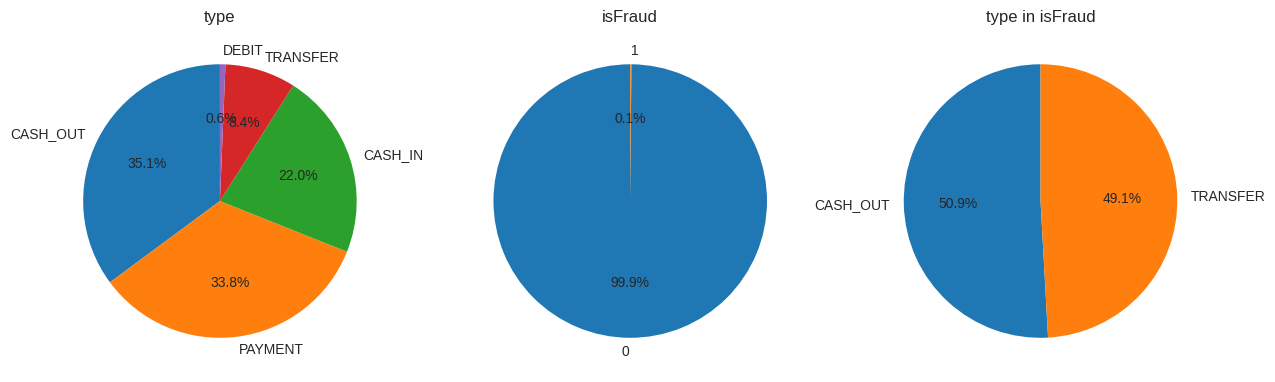

In [7]:
# Type counts and percentages
counts_type = df['type'].value_counts().rename_axis('type').to_frame('count')
counts_type['Percentage'] = counts_type['count'] / counts_type['count'].sum()

# isFraud counts and percentages
counts_fraud = df['isFraud'].value_counts().rename_axis('isFraud').to_frame('count')
counts_fraud['Percentage'] = counts_fraud['count'] / counts_fraud['count'].sum()

# Filtered fraud transactions
df_f = df[df['isFraud'] == 1]

# Type counts and percentages for frauds only
counts_type_f = df_f['type'].value_counts().rename_axis('type').to_frame('count')
counts_type_f['Percentage'] = counts_type_f['count'] / counts_type_f['count'].sum()

fig, ax1 = plt.subplots(1, 3, figsize=(15,5))
ax1[0].pie(counts_type['Percentage'], labels=counts_type.index, autopct='%1.1f%%', startangle=90)
ax1[0].set_title('type')
ax1[1].pie(counts_fraud['Percentage'], labels=counts_fraud.index, autopct='%1.1f%%', startangle=90)
ax1[1].set_title('isFraud')
ax1[2].pie(counts_type_f['Percentage'], labels=counts_type_f.index, autopct='%1.1f%%', startangle=90)
ax1[2].set_title('type in isFraud')



In [8]:
# Since there is fraud only in CASH_OUT and TRANSFER, we will filter the dataset to only include these types.
# This will help us focus on the most relevant transactions for fraud detection.
# Filter to only fraud-prone transaction types
print(f"Original dataset size: {len(df):,}")
df_filtered = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
print(f"Filtered dataset size: {len(df_filtered):,}")
print(f"Reduction: {(1 - len(df_filtered)/len(df))*100:.1f}%")
df = df_filtered

Original dataset size: 600,000
Filtered dataset size: 260,921
Reduction: 56.5%


In [9]:
# Check fraud distribution
print("\nFraud distribution:")
print(df['isFraud'].value_counts())
print(f"fraud rate: {df['isFraud'].mean()*100:.2f}%")


Fraud distribution:
isFraud
0    260123
1       798
Name: count, dtype: int64
fraud rate: 0.31%


Text(0.5, 1.0, 'type in isFraud')

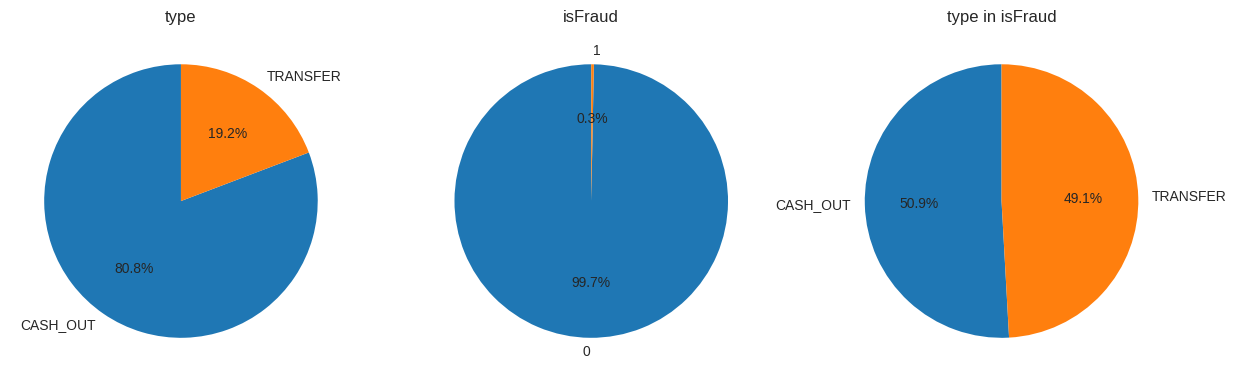

In [10]:
# Type counts and percentages
counts_type = df['type'].value_counts().rename_axis('type').to_frame('count')
counts_type['Percentage'] = counts_type['count'] / counts_type['count'].sum()

# isFraud counts and percentages
counts_fraud = df['isFraud'].value_counts().rename_axis('isFraud').to_frame('count')
counts_fraud['Percentage'] = counts_fraud['count'] / counts_fraud['count'].sum()

# Filtered fraud transactions
df_f = df[df['isFraud'] == 1]

# Type counts and percentages for frauds only
counts_type_f = df_f['type'].value_counts().rename_axis('type').to_frame('count')
counts_type_f['Percentage'] = counts_type_f['count'] / counts_type_f['count'].sum()

fig, ax1 = plt.subplots(1, 3, figsize=(15,5))
ax1[0].pie(counts_type['Percentage'], labels=counts_type.index, autopct='%1.1f%%', startangle=90)
ax1[0].set_title('type')
ax1[1].pie(counts_fraud['Percentage'], labels=counts_fraud.index, autopct='%1.1f%%', startangle=90)
ax1[1].set_title('isFraud')
ax1[2].pie(counts_type_f['Percentage'], labels=counts_type_f.index, autopct='%1.1f%%', startangle=90)
ax1[2].set_title('type in isFraud')

In [11]:
# Run automated profiling
profile = quick_profile(df, export_path='../data/profiling_results.json')

Profile exported to: ../data/profiling_results.json

        Data Quality Summary Report
        Generated on: 2025-08-07T00:53:32.376730

        Basic Information:
        - Rows: 260,921
        - Columns: 11
        - Memory Usage: 67.67 MB

        Class Distribution:
        - Fraud Cases: 798 (0.31%)
        - Normal Cases: 260123
        - Imbalance Ratio: 1:325.97

        Data Quality Issues Found: 1
- [MEDIUM] Found 234469 transactions with balance inconsistencies

Temporal Coverage:
- Duration: 30.88 days (741 hours)


In [10]:
# 1. Check CASH_OUT transactions exceeding balance
cash_out = df[df['type'] == 'CASH_OUT']
invalid_cash_out_mask = (df['type'] == 'CASH_OUT') & (df['amount'] > df['oldbalanceOrg'])
invalid_cash_out = df[invalid_cash_out_mask]
print(f"CASH_OUT transactions exceeding balance: {len(invalid_cash_out):,} ({len(invalid_cash_out)/len(cash_out)*100:.1f}%)")

# 2. Check balance calculations
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

# For TRANSFER and CASH_OUT, sender should lose money
sender_errors = df[abs(df['balance_diff_orig']) > 0.01]
print(f"\nSender balance inconsistencies: {len(sender_errors):,} ({len(sender_errors)/len(df)*100:.1f}%)")

# Recipients should gain money
receiver_errors = df[abs(df['balance_diff_dest']) > 0.01]
print(f"Receiver balance inconsistencies: {len(receiver_errors):,} ({len(receiver_errors)/len(df)*100:.1f}%)")

# 3. Zero balance Pattern
zero_orig_balance = (df['oldbalanceOrg'] == 0) & (df['newbalanceOrig'] == 0) & (df['amount'] > 0)
zero_dest_balance = (df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0) & (df['amount'] > 0)

print("\nTransactions with zero balances throughout:")
print(f"Origin accounts: {zero_orig_balance.sum():,}")
print(f"Destination accounts: {zero_dest_balance.sum():,}")

# 4. Check if these issues correlate with fraud
print("\nFraud rate in inconsistent transactions:")
# Fixed: Use the mask instead of index
print(f"Balance exceeded: {df[invalid_cash_out_mask]['isFraud'].mean()*100:.2f}%")
print(f"Zero balance transactions: {df[zero_orig_balance]['isFraud'].mean()*100:.2f}%")

CASH_OUT transactions exceeding balance: 186,689 (88.6%)

Sender balance inconsistencies: 235,431 (90.2%)
Receiver balance inconsistencies: 53,236 (20.4%)

Transactions with zero balances throughout:
Origin accounts: 123,182
Destination accounts: 546

Fraud rate in inconsistent transactions:
Balance exceeded: 0.00%
Zero balance transactions: 0.00%


In [11]:
# Let's investigate further
print("=== FRAUD PATTERN ANALYSIS ===")

# Where is the fraud actually happening?
fraud_transactions = df[df['isFraud'] == 1]

# Check if fraud follows "normal" balance rules
fraud_with_valid_balance = fraud_transactions[fraud_transactions['amount'] <= fraud_transactions['oldbalanceOrg']]
print(f"\nFraud transactions with valid balances: {len(fraud_with_valid_balance)} / {len(fraud_transactions)} ({len(fraud_with_valid_balance)/len(fraud_transactions)*100:.1f}%)")

# Check balance patterns in fraud vs non-fraud
print("\nBalance patterns in fraud transactions:")
print(fraud_transactions[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig']].head(10))

# The "invalid" transactions might be normal PaySim behavior
valid_balance_mask = (df['amount'] <= df['oldbalanceOrg']) & (abs(df['balance_diff_orig']) <= 0.01)
print(f"\nTransactions following standard balance rules: {valid_balance_mask.sum():,} ({valid_balance_mask.sum()/len(df)*100:.1f}%)")
print(f"Fraud rate in 'valid' balance transactions: {df[valid_balance_mask]['isFraud'].mean()*100:.2f}%")

=== FRAUD PATTERN ANALYSIS ===

Fraud transactions with valid balances: 795 / 798 (99.6%)

Balance patterns in fraud transactions:
           type     amount  oldbalanceOrg  newbalanceOrig
160    TRANSFER 9468064.05     9468064.05            0.00
1591   CASH_OUT  337287.72      337287.72            0.00
3317   CASH_OUT  258570.41      258570.41            0.00
3389   CASH_OUT  322329.78      322329.78            0.00
3836   TRANSFER   46291.81       46291.81            0.00
4951   CASH_OUT 1416055.74     1416055.74            0.00
5809   TRANSFER  465498.74      465498.74            0.00
5979   CASH_OUT   73051.02       73051.02            0.00
9731   TRANSFER   31930.24       31930.24            0.00
10270  CASH_OUT  854065.31      854065.31            0.00

Transactions following standard balance rules: 25,490 (9.8%)
Fraud rate in 'valid' balance transactions: 3.10%


In [12]:
# Let's confirm this pattern
print("=== COMPLETE WITHDRAWAL FRAUD PATTERN ===")

# Check if fraud is mostly complete withdrawals
df['is_complete_withdrawal'] = (df['amount'] == df['oldbalanceOrg']) & (df['newbalanceOrig'] == 0)

print(f"Complete withdrawal transactions: {df['is_complete_withdrawal'].sum():,}")
print(f"Fraud rate in complete withdrawals: {df[df['is_complete_withdrawal']]['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate in partial withdrawals: {df[~df['is_complete_withdrawal']]['isFraud'].mean()*100:.2f}%")

# What percentage of fraud is complete withdrawal?
fraud_complete_withdrawal = df[(df['isFraud']==1) & df['is_complete_withdrawal']].shape[0]
print(f"\n{fraud_complete_withdrawal} out of {df['isFraud'].sum()} fraud cases are complete withdrawals ({fraud_complete_withdrawal/df['isFraud'].sum()*100:.1f}%)")

# Transaction type breakdown
print("\nFraud by transaction type and pattern:")
fraud_pattern = df[df['isFraud']==1].groupby(['type', 'is_complete_withdrawal']).size()
print(fraud_pattern)

=== COMPLETE WITHDRAWAL FRAUD PATTERN ===
Complete withdrawal transactions: 776
Fraud rate in complete withdrawals: 100.00%
Fraud rate in partial withdrawals: 0.01%

776 out of 798 fraud cases are complete withdrawals (97.2%)

Fraud by transaction type and pattern:
type      is_complete_withdrawal
CASH_OUT  False                       3
          True                      403
TRANSFER  False                      19
          True                      373
dtype: int64


In [9]:
# Let's check different transaction types separately
for txn_type in df['type'].unique():
    type_df = df[df['type'] == txn_type].head(5)
    print(f"\n{txn_type} Examples:")
    print(type_df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].to_string())

# Check the actual differences
df['expected_new_orig'] = df['oldbalanceOrg'] - df['amount']
df['expected_new_dest'] = df['oldbalanceDest'] + df['amount']

# See where the discrepancies are
print("\nSample of inconsistencies:")
inconsistent = df[abs(df['newbalanceOrig'] - df['expected_new_orig']) > 0.01].head(10)
print(inconsistent[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'expected_new_orig']].to_string())


CASH_OUT Examples:
      amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
2   57384.49      104661.00        47276.51       153452.69       210837.18
6    1491.37           0.00            0.00       531174.18       532665.55
7   90446.25       40685.00            0.00        69249.07       159695.32
8  158392.49       40716.00            0.00       122443.32       280835.81
10 192727.05           0.00            0.00       587147.48       779874.53

TRANSFER Examples:
       amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest
9  1563250.33           0.00            0.00      2877593.48      4440843.81
11   41139.20           0.00            0.00      4388254.93      4429394.13
19  645377.74           0.00            0.00      1174141.63      1819519.37
52  680940.73           0.00            0.00     13779454.55     14460395.28
85  523697.33           0.00            0.00      1172283.49      1695980.82

Sample of inconsistencies:
        type  

In [14]:
# Create powerful features based on this insight
df['withdrawal_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # Ratio of withdrawal
df['leaves_zero_balance'] = (df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)
df['high_value_complete_withdrawal'] = df['is_complete_withdrawal'] & (df['amount'] > df['amount'].quantile(0.9))

print("\nFeature importance for fraud detection:")
for feature in ['is_complete_withdrawal', 'withdrawal_ratio', 'leaves_zero_balance']:
    fraud_rate = df.groupby(feature)['isFraud'].mean()
    print(f"\n{feature}:")
    print(fraud_rate.head())


Feature importance for fraud detection:

is_complete_withdrawal:
is_complete_withdrawal
False   0.00
True    1.00
Name: isFraud, dtype: float64

withdrawal_ratio:
withdrawal_ratio
0.00   1.00
0.00   0.00
0.00   0.00
0.00   0.00
0.00   0.00
Name: isFraud, dtype: float64

leaves_zero_balance:
leaves_zero_balance
False   0.00
True    0.01
Name: isFraud, dtype: float64


In [20]:
print("\nData types:")
print(df.dtypes)


Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [24]:
# Debug the profiler
profiler = DataProfiler(df)
profile = profiler.generate_profile()

# Check the class distribution directly
print("Class distribution from profile:")
print(profile['class_distribution'])

# Also check manually
print("\nManual fraud count:")
print(df['isFraud'].value_counts())

Class distribution from profile:
{'error': "No 'is_fraud' column found"}

Manual fraud count:
isFraud
0    599202
1       798
Name: count, dtype: int64


In [22]:
print(df['isFraud'].value_counts())

isFraud
0    599202
1       798
Name: count, dtype: int64


In [17]:
# Check what's happening with the temporal analysis
print("=== TEMPORAL FRAUD ANALYSIS DEBUG ===")

# Group by hour and check
hourly_stats = df.groupby('step').agg({
'isFraud': ['sum', 'count', 'mean']
}).round(4)

# Flatten column names
hourly_stats.columns = ['fraud_count', 'total_count', 'fraud_rate']
hourly_stats['fraud_rate_pct'] = hourly_stats['fraud_rate'] * 100

print("\nFirst 10 hours:")
print(hourly_stats.head(10))

print("\nHours with fraud:")
hours_with_fraud = hourly_stats[hourly_stats['fraud_count'] > 0]
print(f"Hours with fraud: {len(hours_with_fraud)} out of {len(hourly_stats)}")
print(f"Average fraud rate in hours WITH fraud: {hours_with_fraud['fraud_rate_pct'].mean():.2f}%")

print("\nOverall temporal statistics:")
print(f"Average fraud rate across ALL hours: {hourly_stats['fraud_rate_pct'].mean():.2f}%")
print(f"Hours with 100% fraud rate: {(hourly_stats['fraud_rate_pct'] == 100).sum()}")

# Check those 100% fraud hours
if (hourly_stats['fraud_rate_pct'] == 100).sum() > 0:
    print("\nHours with 100% fraud rate:")
    print(hourly_stats[hourly_stats['fraud_rate_pct'] == 100])

=== TEMPORAL FRAUD ANALYSIS DEBUG ===

First 10 hours:
      fraud_count  total_count  fraud_rate  fraud_rate_pct
step                                                      
1               2           67        0.03            2.99
2               2           17        0.12           11.76
3               0            5        0.00            0.00
4               0            9        0.00            0.00
5               0            9        0.00            0.00
6               2           31        0.06            6.45
7               1          189        0.01            0.53
8               0          746        0.00            0.00
9               1         1528        0.00            0.07
10              2         1455        0.00            0.14

Hours with fraud:
Hours with fraud: 477 out of 641
Average fraud rate in hours WITH fraud: 48.82%

Overall temporal statistics:
Average fraud rate across ALL hours: 36.33%
Hours with 100% fraud rate: 220

Hours with 100% fraud rate:
   